In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import patches
import lightkurve as lk
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.time import Time
from astropy.io import fits
from astropy.wcs import WCS
import fitsio
from tqdm import tqdm

from astroquery.jplhorizons import Horizons
from sbident import SBIdent

from tess_ephem import ephem, TessEphem, log
from tess_asteroid_ml import *
from tess_asteroid_ml.utils import *
from tess_asteroid_ml.make_TESS_asteroid_db import *
# from ipywidgets import *

/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [8]:
maglim = 22

In [9]:
PACKAGEDIR

'/Users/jimartin/Work/TESS/tess-asteroid-ml/tess_asteroid_ml'

In [10]:
def plot_camera_CCD(row, col, image, tracks=None, ax=None, camera=1, ccd=1, track_color=None, show_ax=True):
    if ax is None:
        fig, ax = plt.subplots(1,1)
    if row.shape != col.shape != image.shape:
        raise ValueError("Row, Col or Image have different shapes")

    if camera in [1, 2]:
        if ccd == 1:
            ax.invert_xaxis()
            ax.set_xlim(2091, 44)
            ax.set_ylim(0, 2047)
        elif ccd == 2:
            ax.invert_xaxis()
            ax.set_xlim(2091, 44)
            ax.set_ylim(0, 2047)
        elif ccd == 3:
            ax.invert_yaxis()
            ax.set_xlim(44, 2091)
            ax.set_ylim(2047, 0)
        elif ccd == 4:
            ax.invert_yaxis()
            ax.set_xlim(44, 2091)
            ax.set_ylim(2047, 0)

    if camera in [3, 4]:
        if ccd == 1:
            ax.invert_yaxis()
            ax.set_xlim(44, 2091)
            ax.set_ylim(2047, 0)
        elif ccd == 2:
            ax.invert_yaxis()
            ax.set_xlim(44, 2091)
            ax.set_ylim(2047, 0)
        elif ccd == 3:
            ax.invert_xaxis()
            ax.set_xlim(2091, 44)
            ax.set_ylim(0, 2047)
        elif ccd == 4:
            ax.invert_xaxis()
            ax.set_xlim(2091, 44)
            ax.set_ylim(0, 2047)

    vlo, lo, mid, hi, vhi = np.nanpercentile(image, [0.2, 1, 50, 95, 99.8])
    cnorm = colors.LogNorm(vmin=lo, vmax=vhi)
    ax.pcolormesh(col, row, image, norm=cnorm, cmap="Greys_r", rasterized=True)

    if tracks is not None:
        counter = 0
        for i, (k, val) in enumerate(tracks.items()):
            if len(val) == 0:
                continue
            val = val.query(f"camera == {camera} and ccd == {ccd}")
            if len(val) > 0: 
                counter += 1
                if track_color is not None:
                    cc = track_color[k]
                else:
                    cc = None
                ax.plot(val.column, val.row, "-", lw=.5, rasterized=True, c=cc)
    if show_ax:
        ax.set_title(f"CCD {ccd} | $N$ = {counter}", fontsize="large")
    if not show_ax:
        ax.set(xlabel="", ylabel="")
        ax.tick_params(axis='x', labelbottom=False)
        ax.tick_params(axis='y', labelleft=False)
        ax.set_xticks([])
        ax.set_yticks([])
        
    return ax

['https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/1-1/tess2018356155937-s0006-1-1-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/1-2/tess2018356155937-s0006-1-2-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/1-3/tess2018356155937-s0006-1-3-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/1-4/tess2018356155937-s0006-1-4-0126-s_ffic.fits']
Loading from CSV file...
Asteroid catalog shape (V < 22):  (14535, 23)


100%|███████████████████████████████████████████████████████████████████| 14535/14535 [00:11<00:00, 1212.02it/s]


Asteroid tracks in DB: 13893
Ploting figure...
['https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/2-1/tess2018356155937-s0006-2-1-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/2-2/tess2018356155937-s0006-2-2-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/2-3/tess2018356155937-s0006-2-3-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/2-4/tess2018356155937-s0006-2-4-0126-s_ffic.fits']
Loading from CSV file...
Asteroid catalog shape (V < 22):  (1147, 23)


100%|█████████████████████████████████████████████████████████████████████| 1147/1147 [00:00<00:00, 1232.33it/s]


Asteroid tracks in DB: 1020
Ploting figure...
['https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/3-1/tess2018356155937-s0006-3-1-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/3-2/tess2018356155937-s0006-3-2-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/3-3/tess2018356155937-s0006-3-3-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/3-4/tess2018356155937-s0006-3-4-0126-s_ffic.fits']
Loading from CSV file...
Asteroid catalog shape (V < 22):  (92, 23)


...

Asteroid tracks in DB: 60
Ploting figure...


['https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/4-1/tess2018356155937-s0006-4-1-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/4-2/tess2018356155937-s0006-4-2-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/4-3/tess2018356155937-s0006-4-3-0126-s_ffic.fits', 'https://archive.stsci.edu/missions/tess/ffi/s0006/2018/356/4-4/tess2018356155937-s0006-4-4-0126-s_ffic.fits']
Loading from CSV file...
Asteroid catalog shape (V < 22):  (72, 23)


100%|█████████████████████████████████████████████████████████████████████████| 72/72 [00:00<00:00, 3881.62it/s]

Asteroid tracks in DB: 17
Ploting figure...


drawing arrow


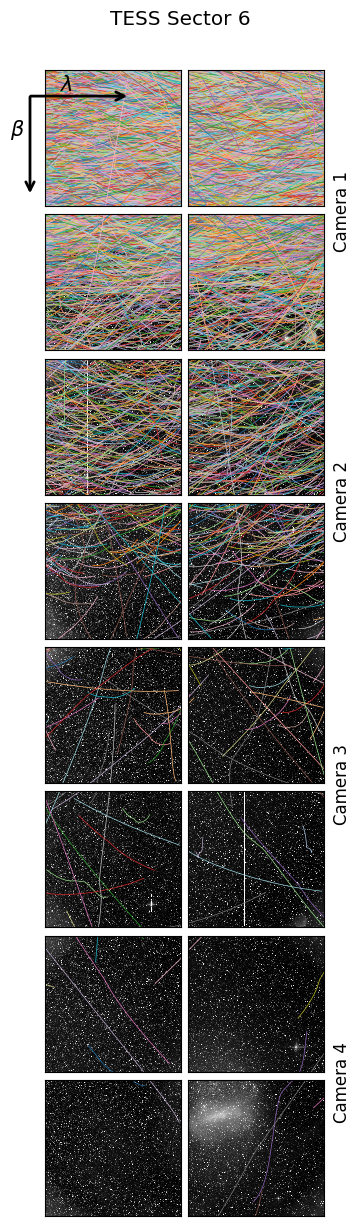

In [22]:
sector_format = True
if sector_format:
    supfig, supax = plt.subplots(8, 2, figsize=(3.6, 14.90))

track_color = {}
MOSAIC_FLUX = {}
MOSAIC_ROW = {}
MOSAIC_COL = {}
MOSAIC_TRACKS = {}
for sector in range(6, 7):
    for camera in range(1, 5):
        ffi_file = get_FFI_name(sector=sector, camera=camera, ccd=0, correct=False)
        print(ffi_file)
    
        with fits.open(ffi_file[0]) as ffi:
            date_obs = Time([ffi[0].header["DATE-OBS"], ffi[0].header["DATE-END"]])
    
        COL, ROW, F = {}, {}, {}
        for k, ccd in enumerate(range(1,5)):
            col_2d, row_2d, f2d = load_ffi_image(
                            "TESS",
                            ffi_file[k],
                            1,
                            None,
                            [0, 0],
                            return_coords=True,
                        )
        
            COL[ccd] = col_2d
            ROW[ccd] = row_2d
            F[ccd] = f2d
        MOSAIC_FLUX[camera] = COL
        MOSAIC_ROW[camera] = ROW
        MOSAIC_COL[camera] = F
    
        scc_str = f"s{sector:04}-{camera}-{0}"
    
        jpl_sbi_file = (f"{os.path.dirname(PACKAGEDIR)}/data/jpl"
                        f"/jpl_small_bodies_tess_{scc_str}_catalog.csv")    
        if os.path.isfile(jpl_sbi_file):
            print("Loading from CSV file...")
            jpl_sb = pd.read_csv(jpl_sbi_file, index_col=0)
    
        jpl_sb_bright = jpl_sb.query(f"V_mag <= {maglim}").reset_index()
        print(f"Asteroid catalog shape (V < {maglim}): ", jpl_sb_bright.shape)
    
        sb_ephems_lowres = {}
    
        for k, row in tqdm(jpl_sb_bright.iterrows(), total=len(jpl_sb_bright)):
            
            feath_file = (f"{os.path.dirname(PACKAGEDIR)}/data/jpl/tracks/sector{sector:04}/"
                          f"tess-ffi_s{sector:04}-0-0_{row['id'].replace(' ', '-')}_hires.feather")
            if os.path.isfile(feath_file):
                ephems_aux = pd.read_feather(feath_file)
                step = len(ephems_aux) // 27 - 1 if len(ephems_aux) > 100 else 4
                sb_ephems_lowres[k] = ephems_aux
                if k not in track_color.keys():
                    track_color[k] = plt.cm.tab20(np.random.randint(0,20))
    
        print(f"Asteroid tracks in DB: {len(sb_ephems_lowres)}")
        MOSAIC_TRACKS[camera] = sb_ephems_lowres

        print("Ploting figure...")

        if sector_format:
            for k, ccd in enumerate(range(1,5)):
                if camera in [1]:
                    if ccd == 1:
                        ax_2 = supax[1, 1]
                    elif ccd == 2:
                        ax_2 = supax[1, 0]
                    elif ccd == 3:
                        ax_2 = supax[0, 0]
                    elif ccd == 4:
                        ax_2 = supax[0, 1]
                if camera in [2]:
                    if ccd == 1:
                        ax_2 = supax[3, 1]
                    elif ccd == 2:
                        ax_2 = supax[3, 0]
                    elif ccd == 3:
                        ax_2 = supax[2, 0]
                    elif ccd == 4:
                        ax_2 = supax[2, 1]
                if camera in [3]:
                    if ccd == 1:
                        ax_2 = supax[4, 0]
                    elif ccd == 2:
                        ax_2 = supax[4, 1]
                    elif ccd == 3:
                        ax_2 = supax[5, 1]
                    elif ccd == 4:
                        ax_2 = supax[5, 0]
                if camera in [4]:
                    if ccd == 1:
                        ax_2 = supax[6, 0]
                    elif ccd == 2:
                        ax_2 = supax[6, 1]
                    elif ccd == 3:
                        ax_2 = supax[7, 1]
                    elif ccd == 4:
                        ax_2 = supax[7, 0]
                ax_2 = plot_camera_CCD(
                    ROW[ccd], COL[ccd], F[ccd], 
                    tracks=sb_ephems_lowres,
                    ax=ax_2, 
                    camera=camera, ccd=ccd, 
                    track_color=track_color, 
                    show_ax=False,
                ) 
                ax_2.set_aspect("equal")

        # if camera == 2: break
    if sector_format:
        supfig.subplots_adjust(wspace=0.05, hspace=0.05)
        supfig.suptitle(f"TESS Sector {sector}", y=0.92, fontsize="x-large")

    if sector <= 13:
        print("drawing arrow")
        supax[0, 0].annotate( 
            "",
            xy=(-15, 50 - 40),            # Arrow head position (data coords)
            xytext=(-15, 152 - 40),       # Arrow tail position (data coords)
            arrowprops=dict(arrowstyle="->", color='k', lw=2),
            clip_on=False,         # Crucial: allows drawing outside the axis box
            ha='center',
            xycoords="axes pixels",
            color="k",
            size=15,
        )
        supax[0, 0].annotate(
                    r'$\beta$', 
                    xy=(-35, 110 - 40),
                    xycoords="axes pixels",
                    size=15,
        )
        supax[0, 0].annotate( 
                    "",
                    xy=(85, 150 - 40),            # Arrow head position (data coords)
                    xytext=(-17, 150 - 40),       # Arrow tail position (data coords)
                    arrowprops=dict(arrowstyle="->", color='k', lw=2),
                    clip_on=False,         # Crucial: allows drawing outside the axis box
                    ha='center',
                    xycoords="axes pixels",
                    color="k",
                    size=15,
                )
        supax[0, 0].annotate(
                    r'$\lambda$', 
                    xy=(15, 155 - 40),
                    xycoords="axes pixels",
                    size=15,
        )
    cam_pos = [0.785, 0.59, 0.4, 0.2]
    for nn, cam in enumerate(range(1, 5)):
        plt.figtext(
            0.95,          # x position (near the right edge of the figure)
            cam_pos[nn],           # y position (vertically centered)
            f'Camera {cam}', # The text
            fontsize="large",
            rotation='vertical',         # Set text to be vertical
            verticalalignment='center',  # Align vertically to the center
            horizontalalignment='center' # Align horizontally to the center
            
        )

    dir_name = f"{os.path.dirname(PACKAGEDIR)}/data/figures/paper_plots"
    if not os.path.isdir(dir_name):
        os.makedirs(dir_name)
    dir_name = (
        f"{dir_name}/tess_ffi_s{sector:04}_asteroid_tracks.pdf"
    )
    # supfig.tight_layout()
    supfig.canvas.draw() 
    supfig.savefig(dir_name, bbox_inches="tight")
    
    plt.show()

Ploting figure...
Ploting figure...
Ploting figure...
Ploting figure...
drawing arrow


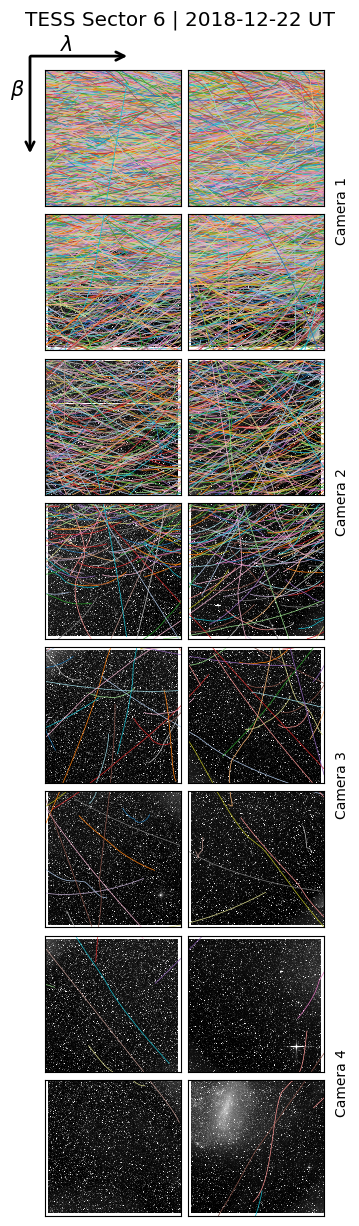

In [12]:
sector_format = True
if sector_format:
    supfig, supax = plt.subplots(8,2,figsize=(3.6,14.90))

# track_color = {}
sector = 6

for camera in range(1, 5):
    print("Ploting figure...")

    if sector_format:
        for k, ccd in enumerate(range(1,5)):
            if camera in [1]:
                if ccd == 1:
                    ax_2 = supax[1, 1]
                elif ccd == 2:
                    ax_2 = supax[1, 0]
                elif ccd == 3:
                    ax_2 = supax[0, 0]
                elif ccd == 4:
                    ax_2 = supax[0, 1]
            if camera in [2]:
                if ccd == 1:
                    ax_2 = supax[3, 1]
                elif ccd == 2:
                    ax_2 = supax[3, 0]
                elif ccd == 3:
                    ax_2 = supax[2, 0]
                elif ccd == 4:
                    ax_2 = supax[2, 1]
            if camera in [3]:
                if ccd == 1:
                    ax_2 = supax[4, 0]
                elif ccd == 2:
                    ax_2 = supax[4, 1]
                elif ccd == 3:
                    ax_2 = supax[5, 1]
                elif ccd == 4:
                    ax_2 = supax[5, 0]
            if camera in [4]:
                if ccd == 1:
                    ax_2 = supax[6, 0]
                elif ccd == 2:
                    ax_2 = supax[6, 1]
                elif ccd == 3:
                    ax_2 = supax[7, 1]
                elif ccd == 4:
                    ax_2 = supax[7, 0]
            ax_2 = plot_camera_CCD(
                MOSAIC_FLUX[camera][ccd], 
                MOSAIC_ROW[camera][ccd], 
                MOSAIC_COL[camera][ccd], 
                tracks=MOSAIC_TRACKS[camera], 
                ax=ax_2, 
                camera=camera, ccd=ccd, 
                track_color=track_color, 
                show_ax=False,
            ) 
            ax_2.set_aspect("equal")

    # if camera == 2: break
if sector_format:
    supfig.subplots_adjust(wspace=0.05, hspace=0.05)
    supfig.suptitle(f"TESS Sector {sector} | {date_obs.mean().iso[:10]} UT", y=0.92, fontsize="x-large")

if sector <= 13:
    print("drawing arrow")
    supax[0, 0].annotate( 
        "",
        xy=(-15, 50),            # Arrow head position (data coords)
        xytext=(-15, 152),       # Arrow tail position (data coords)
        arrowprops=dict(arrowstyle="->", color='k', lw=2),
        clip_on=False,         # Crucial: allows drawing outside the axis box
        ha='center',
        xycoords="axes pixels",
        color="k",
        size=15,
    )
    supax[0, 0].annotate(
                r'$\beta$', 
                xy=(-35, 110),
                xycoords="axes pixels",
                size=15,
    )
    supax[0, 0].annotate( 
                "",
                xy=(85, 150),            # Arrow head position (data coords)
                xytext=(-17, 150),       # Arrow tail position (data coords)
                arrowprops=dict(arrowstyle="->", color='k', lw=2),
                clip_on=False,         # Crucial: allows drawing outside the axis box
                ha='center',
                xycoords="axes pixels",
                color="k",
                size=15,
            )
    supax[0, 0].annotate(
                r'$\lambda$', 
                xy=(15, 155),
                xycoords="axes pixels",
                size=15,
    )
cam_pos = [0.785, 0.59, 0.4, 0.2]
for nn, cam in enumerate(range(1, 5)):
    plt.figtext(
        0.95,          # x position (near the right edge of the figure)
        cam_pos[nn],           # y position (vertically centered)
        f'Camera {cam}', # The text
        rotation='vertical',         # Set text to be vertical
        verticalalignment='center',  # Align vertically to the center
        horizontalalignment='center' # Align horizontally to the center
    )

dir_name = f"{os.path.dirname(PACKAGEDIR)}/data/figures/paper_plots"
if not os.path.isdir(dir_name):
    os.makedirs(dir_name)
dir_name = (
    f"{dir_name}/tess_ffi_s{sector:04}_asteroid_tracks.pdf"
)
# supfig.tight_layout()
# supfig.savefig(dir_name, bbox_inches="tight")
plt.show()

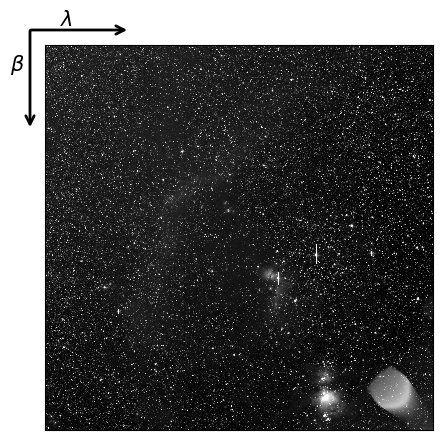

In [45]:
fig, ax = plt.subplots(1,1, figsize=(5,5))

ax_2 = plot_camera_CCD(
                    ROW[1], COL[1], F[1], 
                    # tracks=sb_ephems_lowres, 
                    ax=ax, 
                    camera=1, ccd=1, 
                    # track_color=track_color, 
                    show_ax=False,
                ) 

ax_2.annotate( 
            "",
            xy=(-15, 300),            # Arrow head position (data coords)
            xytext=(-15, 402),       # Arrow tail position (data coords)
            arrowprops=dict(arrowstyle="->", color='k', lw=2),
            clip_on=False,         # Crucial: allows drawing outside the axis box
            ha='center',
            xycoords="axes pixels",
            color="k",
            size=15,
        )
ax_2.annotate(
            r'$\beta$', 
            xy=(-35, 360),
            xycoords="axes pixels",
            size=15,
)
ax_2.annotate( 
            "",
            xy=(85, 400),            # Arrow head position (data coords)
            xytext=(-17, 400),       # Arrow tail position (data coords)
            arrowprops=dict(arrowstyle="->", color='k', lw=2),
            clip_on=False,         # Crucial: allows drawing outside the axis box
            ha='center',
            xycoords="axes pixels",
            color="k",
            size=15,
        )
ax_2.annotate(
            r'$\lambda$', 
            xy=(15, 405),
            xycoords="axes pixels",
            size=15,
)
plt.show()